In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

386670


In [2]:
import numpy as np
from scipy.ndimage import label, find_objects


def extract_fp_patches(
    true_maps,
    noisy_maps,
    min_size=3,
    max_size=200,
    padding=2,
):
    """
    Extract connected-component FP patches from training maps.

    Parameters
    ----------
    true_maps : list of NxN arrays
    noisy_maps : list of NxN arrays

    min_size : int
        Minimum connected-component size to keep.

    max_size : int
        Maximum connected-component size to keep.

    padding : int
        Extra border around extracted component.

    Returns
    -------
    patches : list of binary arrays
    patch_weights : np.ndarray
        Sampling weights for patches.
    """

    patches = []
    sizes = []

    for T, N in zip(true_maps, noisy_maps):

        T = (np.asarray(T) > 0).astype(np.uint8)
        N = (np.asarray(N) > 0).astype(np.uint8)

        # false positives only
        fp = ((N == 1) & (T == 0)).astype(np.uint8)

        # upper triangle only
        fp = np.triu(fp, 1)

        labeled, ncomp = label(fp)

        objects = find_objects(labeled)

        for idx, slc in enumerate(objects, start=1):

            if slc is None:
                continue

            component = (labeled[slc] == idx)

            comp_size = component.sum()

            if comp_size < min_size:
                continue

            if comp_size > max_size:
                continue

            r0, r1 = slc[0].start, slc[0].stop
            c0, c1 = slc[1].start, slc[1].stop

            r0 = max(0, r0 - padding)
            r1 = min(fp.shape[0], r1 + padding)

            c0 = max(0, c0 - padding)
            c1 = min(fp.shape[1], c1 + padding)

            patch = fp[r0:r1, c0:c1].copy()

            patches.append(patch)
            sizes.append(comp_size)

    if len(patches) == 0:
        raise ValueError("No valid patches extracted.")

    # --------------------------------------------------------
    # Patch sampling weights
    # Smaller patches slightly favored
    # --------------------------------------------------------

    sizes = np.asarray(sizes, dtype=float)

    patch_weights = 1 / np.sqrt(sizes)
    patch_weights /= patch_weights.sum()

    return patches, patch_weights


In [3]:
def estimate_fp_distance_density(
    true_maps,
    noisy_maps,
    n_bins=50,
    smooth=1e-6,
):
    """
    Estimate FP density as a function of
    distance to diagonal.
    """

    counts = np.zeros(n_bins)
    totals = np.zeros(n_bins)

    for T, N in zip(true_maps, noisy_maps):

        T = (np.asarray(T) > 0).astype(np.uint8)
        N = (np.asarray(N) > 0).astype(np.uint8)

        fp = ((N == 1) & (T == 0)).astype(np.uint8)

        n = T.shape[0]

        for i in range(n):
            for j in range(i + 1, n):

                # only valid FP locations
                if T[i, j] == 1:
                    continue

                d = abs(i - j) / (n - 1)

                b = min(int(d * n_bins), n_bins - 1)

                totals[b] += 1
                counts[b] += fp[i, j]

    density = (counts + smooth) / (totals + smooth)

    # normalize for rejection sampling
    density /= density.max()

    return density


In [4]:
class ClusterNoiseGenerator:

    def __init__(
        self,
        fp_patches,
        patch_weights,
        distance_density,
        random_state=0,
    ):

        self.fp_patches = fp_patches
        self.patch_weights = patch_weights
        self.distance_density = distance_density

        self.rng = np.random.default_rng(random_state)

    # --------------------------------------------------------
    # SAMPLE SEED
    # --------------------------------------------------------

    def _sample_seed(self, true_map):

        n = true_map.shape[0]

        while True:

            i = self.rng.integers(0, n - 1)
            j = self.rng.integers(i + 1, n)

            # cannot create FP on true contact
            if true_map[i, j] == 1:
                continue

            d = abs(i - j) / (n - 1)

            b = min(
                int(d * len(self.distance_density)),
                len(self.distance_density) - 1,
            )

            # rejection sampling according to distance profile
            if self.rng.random() < self.distance_density[b]:
                return i, j

    # --------------------------------------------------------
    # RANDOM PATCH TRANSFORMATIONS
    # --------------------------------------------------------

    def _transform_patch(self, patch):

        p = patch.copy()

        # transpose
        if self.rng.random() < 0.5:
            p = p.T

        # vertical flip
        if self.rng.random() < 0.5:
            p = np.flipud(p)

        # horizontal flip
        if self.rng.random() < 0.5:
            p = np.fliplr(p)

        return p

    # --------------------------------------------------------
    # SAMPLE PATCH
    # --------------------------------------------------------

    def _sample_patch(self):

        idx = self.rng.choice(
            len(self.fp_patches),
            p=self.patch_weights,
        )

        patch = self.fp_patches[idx]

        patch = self._transform_patch(patch)

        return patch

    # --------------------------------------------------------
    # GENERATE NOISY MAP
    # --------------------------------------------------------

    def generate(
        self,
        true_map,
        target_fp_fraction=0.03,
        max_clusters=500,
    ):
        """
        Generate synthetic noisy map.

        Parameters
        ----------
        true_map : NxN binary array

        target_fp_fraction : float
            Fraction of valid positions to occupy
            with false positives.

        max_clusters : int
            Safety limit.

        Returns
        -------
        noisy : binary array
        fp : binary FP mask
        """

        T = (np.asarray(true_map) > 0).astype(np.uint8)

        n = T.shape[0]

        # valid FP positions
        valid = (
            np.triu(np.ones_like(T, dtype=bool), 1)
            & (T == 0)
        )

        target_fp = int(target_fp_fraction * valid.sum())

        fp = np.zeros_like(T, dtype=np.uint8)

        current_fp = 0

        for _ in range(max_clusters):

            if current_fp >= target_fp:
                break

            # ------------------------------------------------
            # sample seed
            # ------------------------------------------------

            seed_i, seed_j = self._sample_seed(T)

            # ------------------------------------------------
            # sample empirical patch
            # ------------------------------------------------

            patch = self._sample_patch()

            ph, pw = patch.shape

            # place patch centered on seed
            r0 = seed_i - ph // 2
            c0 = seed_j - pw // 2

            # ------------------------------------------------
            # stamp patch
            # ------------------------------------------------

            for u in range(ph):
                for v in range(pw):

                    if patch[u, v] == 0:
                        continue

                    x = r0 + u
                    y = c0 + v

                    # bounds
                    if x < 0 or x >= n:
                        continue

                    if y < 0 or y >= n:
                        continue

                    # upper triangle only
                    if x >= y:
                        continue

                    # cannot overwrite true contact
                    if T[x, y] == 1:
                        continue

                    fp[x, y] = 1
                    fp[y, x] = 1

            current_fp = fp[valid].sum()

        # ----------------------------------------------------
        # enforce symmetry
        # ----------------------------------------------------

        fp = np.triu(fp, 1)
        fp = fp + fp.T

        np.fill_diagonal(fp, 0)

        noisy = np.maximum(T, fp)

        return noisy.astype(np.uint8), fp.astype(np.uint8)

In [5]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  


def top_k_mask(matrix, k):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask[rows, cols] = 1
    mask[cols, rows] = 1

    return mask

In [6]:
folder_path = "Data"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

In [7]:
true_maps=[]
noisy_maps=[]
for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    true_maps.append(contact_map)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)
    noisy_maps.append(binary_map)

In [8]:
patches, patch_weights = extract_fp_patches(
    true_maps,
    noisy_maps,
    min_size=3,
    max_size=100,
    padding=2,
)

density = estimate_fp_distance_density(
    true_maps,
    noisy_maps,
    n_bins=50,
)

generator = ClusterNoiseGenerator(
    fp_patches=patches,
    patch_weights=patch_weights,
    distance_density=density,
    random_state=123,
)


In [9]:
#Take statistical informnation from the dca data, for each distance the total number of link, true postive and false positive is annotated

stats=np.zeros((300,3))

true_cm=[]
fake_cm=[]
for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    true_cm.append(contact_map)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)
    fake_cm.append(binary_map)
    
    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            if isfinite[i][j]:

                d = int(dist[i, j])
                stats[d, 2] += 1  # total pairs at distance d

                if binary_map[i, j]==1:

                    if contact_map[i, j]==1:
                        #true positives
                        stats[d, 0] += 1

                    elif contact_map[i, j]==0:
                        #false positives
                        stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_386670/3042094204.py:43: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_386670/3042094204.py:44: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


In [10]:
#taking the probability distribution of the contacts this function make noisy PDB

def sample_noisy_contact_map_from_distance(
    distance_map,
    p_detect_by_r,
    K,
    threshold=8.0,
    seed=None,
):
    """
    Generate a noisy contact map using detection probabilities vs real distance.

    Parameters
    ----------
    distance_map : (L, L) array
        Real-valued distance matrix.
    p_detect_by_r : array-like
        p_detect_by_r[r] = probability of predicting a contact at distance r
        (r is assumed to be int(distance)).
    K : int
        Total number of predicted contacts
    threshold : float
        Distance threshold separating true (<= threshold) and false (> threshold).
    seed : int or None

    Returns
    -------
    new_map : (L, L) int8 array
    stats : dict
        Contains counts of true/false contacts.
    """
    rng = np.random.default_rng(seed)

    D = np.asarray(distance_map)
    L = D.shape[0]

    # --- consider only upper triangle (i < j)
    i, j = np.triu_indices(L, k=1)

    dvals = D[i, j]
    valid = np.isfinite(dvals)

    i = i[valid]
    j = j[valid]
    dvals = dvals[valid]

    # --- convert distances to integer bins
    r = np.floor(dvals).astype(int)
    r = np.clip(r, 0, len(p_detect_by_r) - 1)

    # --- weights from empirical detection probability
    w = p_detect_by_r[r].astype(float)

    # avoid degenerate case
    if np.all(w == 0):
        raise ValueError("All detection probabilities are zero.")

    # --- split into true / false according to threshold
    true_mask = dvals <= threshold
    false_mask = dvals > threshold

    # weights per group
    w_true = w[true_mask]
    w_false = w[false_mask]

    # --- total weight
    W_true = w_true.sum()
    W_false = w_false.sum()
    W_total = W_true + W_false

    if W_total == 0:
        raise ValueError("Total weight is zero.")

    # --- allocate number of contacts
    K_true = int(round(K * W_true / W_total))
    K_false = K - K_true

    # --- indices
    true_i, true_j = i[true_mask], j[true_mask]
    false_i, false_j = i[false_mask], j[false_mask]

    # --- safety checks
    K_true = min(K_true, len(true_i))
    K_false = min(K_false, len(false_i))

    # --- probabilities within each group
    if len(w_true) > 0:
        p_true = w_true / w_true.sum()
        idx_true = rng.choice(len(true_i), size=K_true, replace=False, p=p_true)
    else:
        idx_true = np.array([], dtype=int)

    if len(w_false) > 0:
        p_false = w_false / w_false.sum()
        idx_false = rng.choice(len(false_i), size=K_false, replace=False, p=p_false)
    else:
        idx_false = np.array([], dtype=int)

    # --- build output map
    new_map = np.zeros((L, L), dtype=np.int8)

    # true contacts
    ti = true_i[idx_true]
    tj = true_j[idx_true]
    new_map[ti, tj] = 1
    new_map[tj, ti] = 1

    # false contacts
    fi = false_i[idx_false]
    fj = false_j[idx_false]
    new_map[fi, fj] = 1
    new_map[fj, fi] = 1

    stats = {
        "K_total": K,
        "K_true": len(idx_true),
        "K_false": len(idx_false),
        "fraction_true": len(idx_true) / K if K > 0 else 0.0,
    }

    return new_map, stats

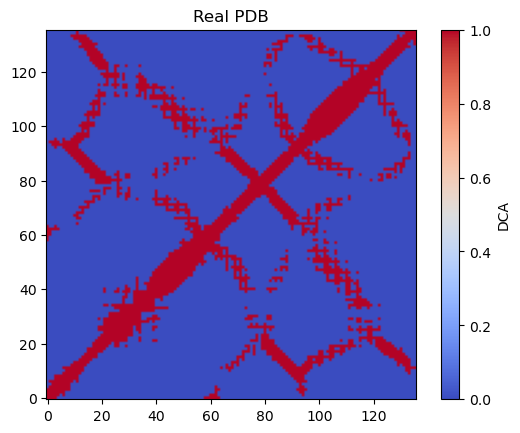

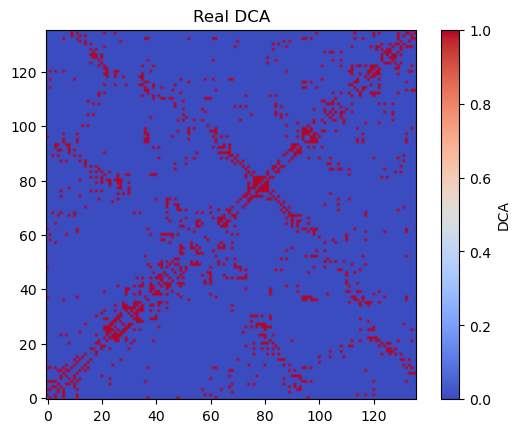

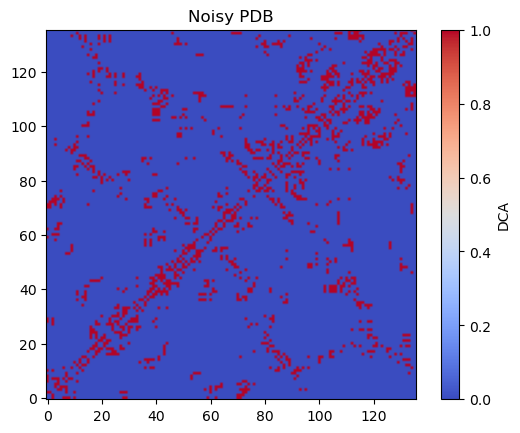

In [14]:
index=739

t_cm=true_cm[index]

fake_noisy, fake_fp = generator.generate(
    t_cm,
    target_fp_fraction=0.05,
)


# remove overlap with true contacts
fake_fp = fake_fp * (1 - t_cm)
p_detect_by_r = total_percentage
L= distance_map[index].shape[0]
K = 5 * L
new_map, __ = sample_noisy_contact_map_from_distance(distance_map[index],p_detect_by_r,K,threshold=8.0,seed=1)

true_positives = (new_map == 1) & (t_cm == 1)

fake_noisy = np.maximum(true_positives, fake_fp)


plt.figure()
plt.imshow(true_maps[index] ,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("Real PDB")
plt.show()

plt.figure()
plt.imshow(noisy_maps[index] ,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("Real DCA")
plt.show()


plt.figure()
plt.imshow(fake_noisy ,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("Noisy PDB")
plt.show()


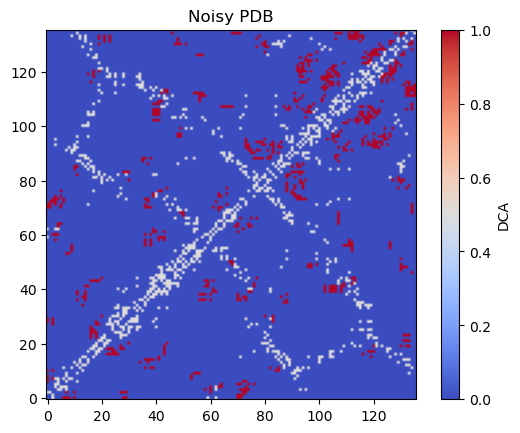

False positive percentage: 5.02%


In [15]:
# combine
fake_noisy = np.maximum(true_positives*0.5, fake_fp)  ###togliere il 0.5, solo per il plot


plt.figure()
plt.imshow(fake_noisy ,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("Noisy PDB")
plt.show()


upper = np.triu(np.ones_like(t_cm, dtype=bool), 1)
valid = upper & (t_cm == 0)

fp_percentage = fake_fp[valid].sum() / valid.sum()
print(f"False positive percentage: {fp_percentage:.2%}")